# Transferencia de Estilos

📸 Si eres un amante de la fotografía, seguramente conoces los filtros. Los filtros pueden cambiar el estilo de color de las fotos: hacer paisajes más nítidos 🌄 o retratos con pieles más blancas 👩🏻. Pero, un filtro solo cambia un aspecto de la foto. Para un estilo ideal, necesitas probar muchas combinaciones de filtros, un proceso tan complejo como ajustar los hiperparámetros de un modelo 📈.

En esta clase, usaremos las capas de una CNN para aplicar automáticamente el estilo de una imagen a otra, es decir, haremos **transferencias de estilos** 🎨.

Necesitamos dos imágenes: una **imagen de contenido** y una **imagen de estilo**. Usaremos redes neuronales para modificar la imagen de contenido y que su estilo se asemeje a la imagen de estilo. Por ejemplo, una foto de un paisaje 🌳 y una pintura al óleo de robles otoñales 🍂. En la imagen final, se aplican los trazos de pincel del óleo, resultando en colores más vivos, pero manteniendo la forma principal del paisaje original 🌅.

![Imgur](https://i.imgur.com/3CVBeNT.png)

## Método

La siguiente figura ilustra el método de transferencia de estilo basado en CNN con un ejemplo simplificado. Primero, inicializamos la imagen sintetizada, por ejemplo, en la imagen de contenido. Esta imagen sintetizada es la única variable que debe actualizarse durante el proceso de transferencia de estilo, es decir, los parámetros del modelo que se actualizarán durante el entrenamiento. Luego, elegimos una CNN preentrenada para extraer las características de la imagen y congelamos los parámetros de su modelo durante el entrenamiento. Esta CNN profunda utiliza varias capas para extraer características jerárquicas de las imágenes. Podemos elegir la salida de algunas de estas capas como características de contenido o características de estilo. En el ejemplo de la figura, la red neuronal preentrenada aquí tiene 3 capas convolucionales, donde la segunda capa genera las características de contenido y la primera y la tercera capas generan las características de estilo.

![Imgur](https://i.imgur.com/sBdtUJj.png)

A continuación, calculamos la función de pérdida de la transferencia de estilo a través de la propagación hacia adelante (dirección de las flechas continuas) y actualizamos los parámetros del modelo (la imagen sintetizada para la salida) a través de la propagación hacia atrás (dirección de las flechas discontinuas).

La función de pérdida comúnmente utilizada en la transferencia de estilo consta de tres partes:
1. la **pérdida de contenido** hace que la imagen sintetizada y la imagen de contenido se acerquen en características de contenido;
2. la **pérdida de estilo** hace que la imagen sintetizada y la imagen de estilo se acerquen en características de estilo; y
3. la **pérdida de variación total** ayuda a reducir el ruido en la imagen sintetizada.

Finalmente, cuando finaliza el entrenamiento del modelo, generamos los parámetros del modelo de la transferencia de estilo para generar la imagen sintetizada final. A continuación, explicaremos los detalles técnicos de la transferencia de estilo a través de un experimento concreto.

## Implementación
### Leer las imágenes de estilo y de contenido

Primero, leemos el contenido y el estilo de las imágenes. A partir de sus ejes de coordenadas impresos, podemos decir que estas imágenes tienen diferentes tamaños.


In [ ]:
# Esta línea habilita la visualización de gráficos en línea utilizando matplotlib
%matplotlib inline

# Importación de las bibliotecas necesarias
import torch
import torchvision
from torch import nn
from matplotlib import pyplot as plt
from PIL import Image


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


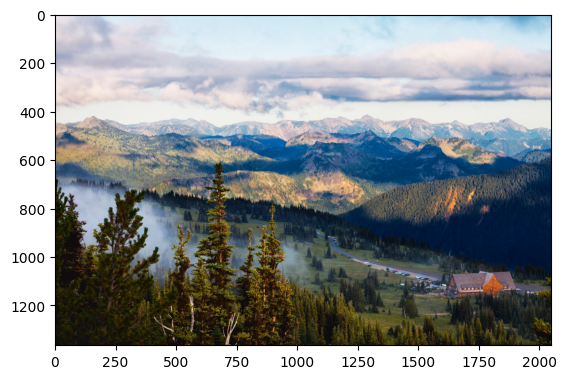

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

content_img_path = ('/content/drive/MyDrive/autumn-oaks.jpeg')
content_img = Image.open(content_img_path)
plt.imshow(content_img)


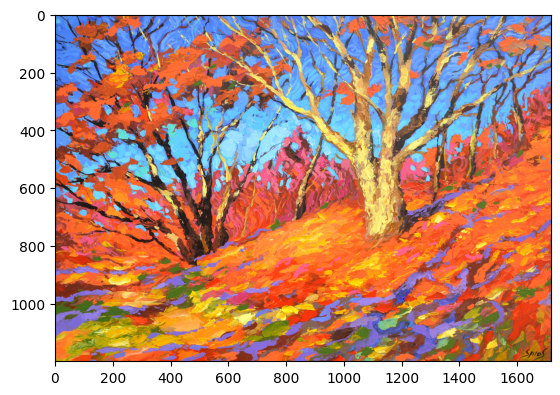

In [ ]:
style_img = Image.open('/content/drive/MyDrive/rainier.jpeg')
plt.imshow(style_img)

### Preprocesamiento y posprocesamiento

A continuación, definimos dos funciones para el preprocesamiento y el posprocesamiento de imágenes. La función `preprocess` estandariza cada uno de los tres canales RGB de la imagen de entrada y transforma los resultados al formato de entrada CNN. La función `postprocess` restaura los valores de píxeles en la imagen de salida a sus valores originales antes de la estandarización. Dado que la función de impresión de imágenes requiere que cada píxel tenga un valor de punto flotante de 0 a 1, reemplazamos cualquier valor menor que 0 o mayor que 1 con 0 o 1, respectivamente.


In [ ]:
# Definir las medias y desviaciones estándar para la normalización de las imágenes
# Estos valores se calculan a partir de grandes conjuntos de datos de imágenes como ImageNet.
# Representan las medias y desviaciones estándar de los valores de píxeles en los canales R, G y B respectivamente.
rgb_mean = torch.tensor([0.485, 0.456, 0.406])  # Medias para los canales R (0.485), G (0.456) y B (0.406) en ImageNet
rgb_std = torch.tensor([0.229, 0.224, 0.225])   # Desviaciones estándar para los canales R (0.229), G (0.224) y B (0.225) en ImageNet

# Función para preprocesar la imagen antes de pasarla por la red neuronal
def preprocess(img, image_shape):
    # Componer una secuencia de transformaciones de imágenes
    transforms = torchvision.transforms.Compose([
        torchvision.transforms.Resize(image_shape),  # Cambiar el tamaño de la imagen a 'image_shape' (una tupla con las dimensiones deseadas)
        torchvision.transforms.ToTensor(),           # Convertir la imagen a un tensor (normaliza los valores de píxeles entre 0 y 1)
        torchvision.transforms.Normalize(mean=rgb_mean, std=rgb_std)])  # Normalizar la imagen usando las medias y desviaciones estándar definidas
    # Aplicar las transformaciones a la imagen y agregar una dimensión adicional para el lote
    return transforms(img).unsqueeze(0)  # Añadir una dimensión para el lote (batch size de 1)

# Función para procesar la imagen después de pasarla por la red neuronal
def postprocess(img):
    # Mover la imagen a la misma GPU/CPU donde se encuentran las medias y desviaciones estándar
    img = img[0].to(rgb_std.device)  # Seleccionar la primera imagen del lote (índice 0) y moverla al dispositivo (GPU/CPU) de rgb_std
    # Invertir la normalización y asegurarse de que los valores de píxeles estén en el rango [0, 1]
    img = torch.clamp(img.permute(1, 2, 0) * rgb_std + rgb_mean, 0, 1)  # Reordenar las dimensiones del tensor, desnormalizar y asegurar que los valores estén entre 0 y 1
    # Convertir el tensor de imagen de nuevo a la imagen de Pillow (PIL) y reorganizar las dimensiones
    return torchvision.transforms.ToPILImage()(img.permute(2, 0, 1))  # Reordenar las dimensiones del tensor y convertirlo de nuevo a una imagen PIL

### Extracción de características

Usamos el modelo VGG-19 preentrenado en el conjunto de datos de ImageNet para extraer las características de la imagen.


In [ ]:
pretrained_net = torchvision.models.vgg19(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:05<00:00, 103MB/s]


Para extraer las características de contenido y las características de estilo de la imagen, podemos seleccionar la salida de ciertas capas en la red VGG. En términos generales, cuanto más cerca de la capa de entrada, más fácil extraer detalles de la imagen y mientras más lejos, más fácil extraer la información global de la imagen. Para evitar retener excesivamente los detalles de la imagen de contenido en la imagen sintetizada, elegimos una capa VGG que está más cerca de la salida como **capa de contenido** para generar las características de contenido de la imagen. También seleccionamos la salida de diferentes capas VGG para extraer características de estilo locales y globales. Estas capas también se denominan **capas de estilo**.

La red VGG usa 5 bloques convolucionales. En este experimento, elegimos la última capa convolucional del cuarto bloque convolucional como la capa de contenido y la primera capa convolucional de cada bloque convolucional como la capa de estilo. Los índices de estas capas se pueden obtener imprimiendo la instancia `pretrained_net`.




In [ ]:
import torchvision.models as models  # Asegúrate de importar el módulo models

#Cargar la red VGG-19 preentrenada
pretrained_net = models.vgg19(pretrained=True)

# Imprimir la estructura de la red VGG-19
print(pretrained_net)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
# Definir las capas que se utilizarán para el estilo y el contenido
style_layers = [0, 5, 10, 19, 28]  # Índices de las capas para el estilo
content_layers = [25]               # Índices de las capas para el contenido


Al extraer características usando capas VGG, solo necesitamos usar todas aquellas desde la capa de entrada hasta la capa de contenido o la capa de estilo más cercana a la capa de salida. Construyamos una nueva red `net`, que solo conserve las capas VGG que se utilizarán para la extracción de características.


In [ ]:
# Crear una red neuronal secuencial
net = nn.Sequential(
    # Seleccionar las capas de la red preentrenada indicadas por los índices en content_layers y style_layers
    *[pretrained_net.features[i] for i in range(max(content_layers + style_layers) + 1)]
)


Dada la entrada `X`, si simplemente invocamos la función forward `net(X)`, solo podemos obtener la salida de la última capa. Dado que también necesitamos las salidas de las capas intermedias, debemos realizar cálculos capa por capa y mantener las salidas de las capas de contenido y estilo.


In [ ]:
def extract_features(X, content_layers, style_layers):
    # Inicializar listas para almacenar las características de contenido y estilo
    contents = []
    styles = []

    # Iterar sobre las capas de la red neuronal
    for i in range(len(net)):
        # Propagar la entrada a través de la red neuronal hasta la capa i
        X = net[i](X)

        # Verificar si la capa actual es una capa de estilo y agregar sus características a la lista de estilos
        if i in style_layers:
            styles.append(X)

        # Verificar si la capa actual es una capa de contenido y agregar sus características a la lista de contenidos
        if i in content_layers:
            contents.append(X)

    # Devolver las características de contenido y estilo extraídas
    return contents, styles


A continuación se definen dos funciones: la función `get_contents` extrae características de contenido de la imagen de contenido y la función `get_styles` extrae características de estilo de la imagen de estilo. Dado que no es necesario actualizar los parámetros del modelo VGG preentrenado durante el entrenamiento, podemos extraer el contenido y las características de estilo incluso antes de que comience el entrenamiento. Dado que la imagen sintetizada sí es un conjunto de parámetros del modelo que se actualizará para la transferencia de estilo, solo podemos extraer el contenido y las características de estilo de la imagen sintetizada llamando a la función `extract_features` durante el entrenamiento.

In [ ]:
def get_contents(image_shape, device):
    # Preprocesar la imagen de contenido y llevarla al dispositivo especificado
    content_X = preprocess(content_img, image_shape).to(device)

    # Extraer características de contenido de la imagen de contenido
    contents_Y, _ = extract_features(content_X, content_layers, style_layers)

    # Devolver la imagen de contenido preprocesada y sus características de contenido
    return content_X, contents_Y

def get_styles(image_shape, device):
    # Preprocesar la imagen de estilo y llevarla al dispositivo especificado
    style_X = preprocess(style_img, image_shape).to(device)

    # Extraer características de estilo de la imagen de estilo
    _, styles_Y = extract_features(style_X, content_layers, style_layers)

    # Devolver la imagen de estilo preprocesada y sus características de estilo
    return style_X, styles_Y



### Definición de la función de pérdida

Ahora describiremos la función de pérdida para la transferencia de estilo. La función de pérdida consiste en la pérdida de contenido, la pérdida de estilo y la pérdida de variación total.



#### Pérdida de contenido

Similar a la función de pérdida en la regresión lineal, la pérdida de contenido mide la diferencia en las características de contenido entre la imagen sintetizada y la imagen de contenido a través del error cuadrático medio.

In [ ]:
def content_loss(Y_hat, Y):
    """
    Calcula la pérdida de contenido entre la imagen generada Y_hat y la imagen objetivo Y.

    Args:
    - Y_hat: Características de contenido de la imagen generada.
    - Y: Características de contenido de la imagen objetivo.

    Returns:
    - content_loss: Pérdida de contenido entre Y_hat y Y.
    """

    # Calcula la diferencia cuadrada entre las características de contenido de la imagen generada y la imagen objetivo
    content_loss = torch.square(Y_hat - Y.detach()).mean()
    # `Y.detach()` se utiliza para separar `Y` del grafo computacional para evitar el cálculo de gradientes en `Y`.
    # `torch.square(Y_hat - Y.detach()).mean()` calcula la media del error cuadrático.

    # Devuelve la pérdida de contenido calculada
    return content_loss


#### Pérdida de estilo

La pérdida de estilo, similar a la pérdida de contenido, también utiliza el error cuadrático medio para medir la diferencia de estilo entre la imagen sintetizada y la imagen de estilo. Para expresar la salida de estilo de cualquier capa de estilo, primero usamos la función `extract_features` para calcular la salida de la capa de estilo. Suponiendo que la salida tiene 1 ejemplo, $c$ canales, altura $h$ y ancho $w$, podemos transformar esta salida en una matriz $\mathbf{X}$ con $c$ filas y $hw$ columnas. Esta matriz se puede considerar como la concatenación de $c$ vectores $\mathbf{x}_1, \ldots, \mathbf{x}_c$, cada uno de los cuales tiene una longitud de $hw$. Aquí, el vector $\mathbf{x}_i$ representa la función de estilo del canal $i$.

![Imgur](https://i.imgur.com/HCFyiLm.png)

Luego crearemos una ***matriz de Gram*** a partir de estos vectores. En esta matriz $\mathbf{X}\mathbf{X}^\top \in \mathbb{R}^{c \times c}$, el elemento $x_{ij}$ en la fila $i $ y la columna $j$ es el producto escalar de los vectores $\mathbf{x}_i$ y $\mathbf{x}_j$. Esto representa la correlación de las características de estilo de los canales $i$ y $j$.

![Imgur](https://i.imgur.com/R7isL94.png)
Usamos esta matriz de Gram para representar la salida de estilo de cualquier capa de estilo. Tenga en cuenta que cuando el valor de $hw$ es mayor, es probable que genere valores mayores en la matriz de Gram. Tenga en cuenta también que el alto y el ancho de la matriz Gram son ambos el número de canales $c$. Para permitir que la pérdida de estilo no se vea afectada por estos valores, la siguiente función `gram` divide la matriz Gram por el número de sus elementos, es decir, $chw$.


In [ ]:
def gram(X):
    """
    Calcula la matriz Gram de las características de entrada.

    Args:
    - X: Características de entrada.

    Returns:
    - gram_matrix: Matriz Gram de las características de entrada.
    """

    # Obtiene el número de canales y el número total de elementos en las características de entrada
    num_channels, n = X.shape[1], X.numel() // X.shape[1]
    # `X.shape[1]` obtiene el número de canales (la segunda dimensión de X).
    # `X.numel()` obtiene el número total de elementos en X.
    # `X.numel() // X.shape[1]` calcula el número de elementos por canal.

    # Reorganiza las características de entrada para que tenga la forma (num_channels, n)
    X = X.reshape((num_channels, n))
    # `X.reshape((num_channels, n))` cambia la forma de X para que tenga `num_channels` filas y `n` columnas.

    # Calcula la matriz Gram multiplicando la matriz de características por su traspuesta
    # y luego normalizando el resultado por el número de canales y el número total de elementos
    gram_matrix = torch.matmul(X, X.T) / (num_channels * n)
    # `torch.matmul(X, X.T)` realiza la multiplicación matricial de X por su traspuesta, resultando en una matriz de forma (num_channels, num_channels).
    # La multiplicación se normaliza dividiendo por el producto del número de canales y el número total de elementos.

    # Devuelve la matriz Gram calculada
    return gram_matrix


Obviamente, las dos matrices de Gram que son entradas de la pérdida de estilo se basan en las salidas de la capa de estilo para la imagen sintetizada y la imagen de estilo. Aquí se supone que la matriz de Gram gram_Y basada en la imagen de estilo ha sido precalculada.


In [ ]:
def style_loss(Y_hat, gram_Y):
    """
    Calcula la pérdida de estilo entre las características de estilo de la imagen generada Y_hat y las características de estilo de la imagen objetivo gram_Y.

    Args:
    - Y_hat: Características de estilo de la imagen generada.
    - gram_Y: Matriz Gram de las características de estilo de la imagen objetivo.

    Returns:
    - style_loss: Pérdida de estilo entre Y_hat y gram_Y.
    """

    # Calcula la matriz Gram de las características de estilo de la imagen generada Y_hat
    gram_Y_hat = gram(Y_hat)

    # Calcula la diferencia cuadrada entre las matrices Gram de Y_hat y gram_Y, y luego toma la media
    style_loss = torch.square(gram_Y_hat - gram_Y.detach()).mean()

    # Devuelve la pérdida de estilo calculada
    return style_loss


#### Pérdida de variación total

A veces, la imagen sintetizada aprendida tiene mucho ruido de alta frecuencia, es decir, píxeles particularmente brillantes u oscuros. Un método común de reducción de ruido es la ***eliminación de ruido de variación total***. Denote por $x_{i, j}$ el valor del píxel en la coordenada $(i, j)$. Reducir la pérdida de variación total definida como

$$\sum_{i, j} \left|x_{i, j} - x_{i+1, j}\right| + \left|x_{i, j} - x_{i, j+1}\right|$$

acerca los valores de los píxeles vecinos en la imagen sintetizada.


In [ ]:
def tv_loss(Y_hat):
    """
    Calcula la pérdida de regularización total variacional (TV) para la imagen generada Y_hat.

    Args:
    - Y_hat: Imagen generada.

    Returns:
    - tv_loss: Pérdida de regularización total variacional (TV) para Y_hat.
    """

    # Calcula la diferencia absoluta entre los píxeles vecinos en la dimensión vertical y horizontal
    # y luego toma la media de estas diferencias para obtener la pérdida de regularización total variacional
    tv_loss = 0.5 * (
        torch.abs(Y_hat[:, :, 1:, :] - Y_hat[:, :, :-1, :]).mean() +
        # `Y_hat[:, :, 1:, :]` toma la imagen generada excluyendo la primera fila en la dimensión vertical
        # `Y_hat[:, :, :-1, :]` toma la imagen generada excluyendo la última fila en la dimensión vertical
        # La diferencia entre `Y_hat[:, :, 1:, :]` y `Y_hat[:, :, :-1, :]` calcula las diferencias entre píxeles vecinos verticalmente

        torch.abs(Y_hat[:, :, :, 1:] - Y_hat[:, :, :, :-1]).mean()
        # `Y_hat[:, :, :, 1:]` toma la imagen generada excluyendo la primera columna en la dimensión horizontal
        # `Y_hat[:, :, :, :-1]` toma la imagen generada excluyendo la última columna en la dimensión horizontal
        # La diferencia entre `Y_hat[:, :, :, 1:]` y `Y_hat[:, :, :, :-1]` calcula las diferencias entre píxeles vecinos horizontalmente
    )

    # Devuelve la pérdida de regularización total variacional (TV) calculada
    return tv_loss


#### Función de pérdida

La función de pérdida de la transferencia de estilo es la suma ponderada de la pérdida de contenido, la pérdida de estilo y la pérdida de variación total. Al ajustar estos hiperparámetros de peso, podemos equilibrar la retención de contenido, la transferencia de estilo y la reducción de ruido en la imagen sintetizada.


In [ ]:
# Pesos para las pérdidas de contenido, estilo y regularización total variacional (TV)
content_weight, style_weight, tv_weight = 1, 1e3, 10
# content_weight = 1: Este valor se usa para ponderar la importancia de la pérdida de contenido.
# Un valor de 1 significa que la pérdida de contenido se usa tal cual sin escalamiento.
# style_weight = 1e3: Este valor se usa para ponderar la importancia de la pérdida de estilo.
# Un valor de 1000 (1e3) es grande, lo que significa que se da mucha más importancia a la pérdida de estilo comparada con la de contenido.
# tv_weight = 10: Este valor se usa para ponderar la importancia de la pérdida de regularización TV.
# Un valor de 10 ayuda a suavizar la imagen generada, reduciendo el ruido y los artefactos.

def compute_loss(X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram):
    """
    Calcula la pérdida total para la optimización de estilo.

    Args:
    - X: Imagen generada.
    - contents_Y_hat: Características de contenido de la imagen generada.
    - styles_Y_hat: Características de estilo de la imagen generada.
    - contents_Y: Características de contenido de la imagen objetivo.
    - styles_Y_gram: Matrices Gram de las características de estilo de la imagen objetivo.

    Returns:
    - contents_l: Pérdidas de contenido ponderadas.
    - styles_l: Pérdidas de estilo ponderadas.
    - tv_l: Pérdida de regularización total variacional (TV) ponderada.
    - l: Pérdida total.
    """

    # Calcular las pérdidas de contenido ponderadas
    contents_l = [content_loss(Y_hat, Y) * content_weight for Y_hat, Y in zip(contents_Y_hat, contents_Y)]
    # Multiplica cada pérdida de contenido por content_weight (1) para ponderar la pérdida de contenido.

    # Calcular las pérdidas de estilo ponderadas
    styles_l = [style_loss(Y_hat, Y) * style_weight for Y_hat, Y in zip(styles_Y_hat, styles_Y_gram)]
    # Multiplica cada pérdida de estilo por style_weight (1e3) para ponderar la pérdida de estilo.

    # Calcular la pérdida de regularización total variacional (TV) ponderada
    tv_l = tv_loss(X) * tv_weight
    # Multiplica la pérdida TV por tv_weight (10) para ponderar la pérdida de regularización TV.

    # Calcular la pérdida total sumando las pérdidas de contenido, estilo y regularización TV
    l = sum(styles_l + contents_l + [tv_l])
    # Suma todas las pérdidas ponderadas para obtener la pérdida total.

    # Devolver las pérdidas de contenido, estilo y TV ponderadas, así como la pérdida total
    return contents_l, styles_l, tv_l, l


### Inicializar la imagen sintetizada

En la transferencia de estilo, la imagen sintetizada es la única variable que debe actualizarse durante el entrenamiento. Por lo tanto, podemos definir un modelo simple, SynthesizedImage, y tratar a la imagen sintetizada como los parámetros del modelo. En este modelo, la propagación directa solo devuelve los parámetros del modelo.


In [ ]:
class SynthesizedImage(nn.Module):
    def __init__(self, img_shape, **kwargs):
        """
        Inicializa la clase SynthesizedImage.

        Args:
        - img_shape: Forma de la imagen.
        - **kwargs: Argumentos adicionales pasados al constructor de la superclase.

        """
        super(SynthesizedImage, self).__init__(**kwargs)

        # Define un parámetro de peso que representa la imagen sintetizada
        self.weight = nn.Parameter(torch.rand(*img_shape))

    def forward(self):
        """
        Define el paso hacia adelante de la red neuronal.

        Returns:
        - self.weight: El tensor de parámetro que representa la imagen sintetizada.
        """
        return self.weight


A continuación, definimos la función `get_inits`. Esta función crea una instancia de modelo de SynthesizedImage y la inicializa en la imagen `X`. Las matrices Gram para la imagen de estilo en varias capas de estilo, `styles_Y_gram`, se calculan antes del entrenamiento.




In [ ]:
def get_inits(X, device, lr, styles_Y):
    """
    Inicializa la imagen generada, el optimizador y calcula las matrices Gram de las características de estilo.

    Args:
    - X: Imagen inicial.
    - device: Dispositivo en el que se realizarán los cálculos (por ejemplo, 'cuda' para GPU o 'cpu' para CPU).
    - lr: Tasa de aprendizaje para el optimizador.
    - styles_Y: Características de estilo de la imagen objetivo.

    Returns:
    - gen_img: Imagen generada inicializada.
    - styles_Y_gram: Matrices Gram de las características de estilo.
    - trainer: Optimizador utilizado para actualizar la imagen generada.
    """

    # Inicializa la imagen generada con la forma de la imagen inicial y la mueve al dispositivo
    gen_img = SynthesizedImage(X.shape).to(device)

    # Copia los datos de la imagen inicial a la imagen generada
    gen_img.weight.data.copy_(X.data)

    # Inicializa el optimizador Adam para actualizar los parámetros de la imagen generada
    trainer = torch.optim.Adam(gen_img.parameters(), lr=lr)

    # Calcula las matrices Gram de las características de estilo de la imagen objetivo
    styles_Y_gram = [gram(Y) for Y in styles_Y]

    # Devuelve la imagen generada, las matrices Gram de las características de estilo y el optimizador
    return gen_img(), styles_Y_gram, trainer


### Entrenamiento
Al entrenar el modelo para la transferencia de estilo, extraemos continuamente características de contenido y características de estilo de la imagen sintetizada y calculamos la función de pérdida. A continuación se define el ciclo de entrenamiento.


In [ ]:
#markdown Código para animación
from IPython import display  # Importa el módulo display de IPython para mostrar y actualizar figuras

def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """Establece los ejes para matplotlib."""
    axes.set_xlabel(xlabel)  # Establece la etiqueta del eje X
    axes.set_ylabel(ylabel)  # Establece la etiqueta del eje Y
    axes.set_xscale(xscale)  # Establece la escala del eje X (lineal o logarítmica)
    axes.set_yscale(yscale)  # Establece la escala del eje Y (lineal o logarítmica)
    axes.set_xlim(xlim)  # Establece los límites del eje X
    axes.set_ylim(ylim)  # Establece los límites del eje Y
    if legend:  # Si se proporciona una leyenda, configúrala
        axes.legend(legend)
    axes.grid()  # Muestra la cuadrícula en los ejes

class Animator:
    """Para trazar datos en una animación."""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        """Inicializa la clase Animator."""
        if legend is None:
            legend = []
        # Crea una figura y ejes para trazar los datos
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # Configura los ejes
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        # Inicializa listas para almacenar datos de X, Y y formatos de línea
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        """Agrega puntos de datos a la figura."""
        # Si y no es una lista, conviértela en una lista de un solo elemento
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        # Si x no es una lista, conviértela en una lista con la misma longitud que y
        if not hasattr(x, "__len__"):
            x = [x] * n
        # Si no hay datos X almacenados, inicializa una lista para cada serie de datos
        if not self.X:
            self.X = [[] for _ in range(n)]
        # Si no hay datos Y almacenados, inicializa una lista para cada serie de datos
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        # Agrega los datos X e Y a las listas correspondientes
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        # Borra los ejes y traza las series de datos actualizadas
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        # Configura los ejes
        self.config_axes()
        # Muestra la figura
        display.display(self.fig)
        # Limpia la salida para que solo se muestre la figura más reciente
        display.clear_output(wait=True)


In [ ]:
def train(X, contents_Y, styles_Y, device, lr, num_epochs, lr_decay_epoch):
    # Obtiene la imagen inicial, las matrices Gram de las características de estilo y el optimizador
    X, styles_Y_gram, trainer = get_inits(X, device, lr, styles_Y)

    # Define un programador de tasa de aprendizaje que ajusta la tasa de aprendizaje cada lr_decay_epoch épocas
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, lr_decay_epoch, 0.8)

    # Crea un objeto Animator para visualizar la pérdida a lo largo de las épocas
    animator = Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10, num_epochs],
                            legend=['content', 'style', 'TV'],
                            ncols=2, figsize=(20, 10))

    # Itera sobre las épocas de entrenamiento
    for epoch in range(num_epochs):
        # Reinicia los gradientes acumulados en el optimizador
        trainer.zero_grad()

        # Extrae las características de contenido y estilo de la imagen generada
        contents_Y_hat, styles_Y_hat = extract_features(
            X, content_layers, style_layers)

        # Calcula las pérdidas de contenido, estilo y regularización total variacional
        contents_l, styles_l, tv_l, l = compute_loss(
            X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram)

        # Propaga hacia atrás y actualiza los parámetros de la imagen generada
        l.backward()
        trainer.step()

        # Ajusta la tasa de aprendizaje
        scheduler.step()

        # Visualiza la imagen generada y la pérdida cada 10 épocas o durante las primeras 5 épocas
        if (epoch + 1) % 10 == 0 or epoch<5:
            animator.axes[1].imshow(postprocess(X))
            animator.add(epoch + 1, [float(sum(contents_l)),
                                     float(sum(styles_l)), float(tv_l)])

    # Devuelve la imagen generada después del entrenamiento
    return X


Ahora comenzamos a entrenar el modelo. Redimensionamos la altura y el ancho de las imágenes de estilo y contenido a 300 por 450 píxeles. Usamos la imagen de contenido para inicializar la imagen sintetizada.


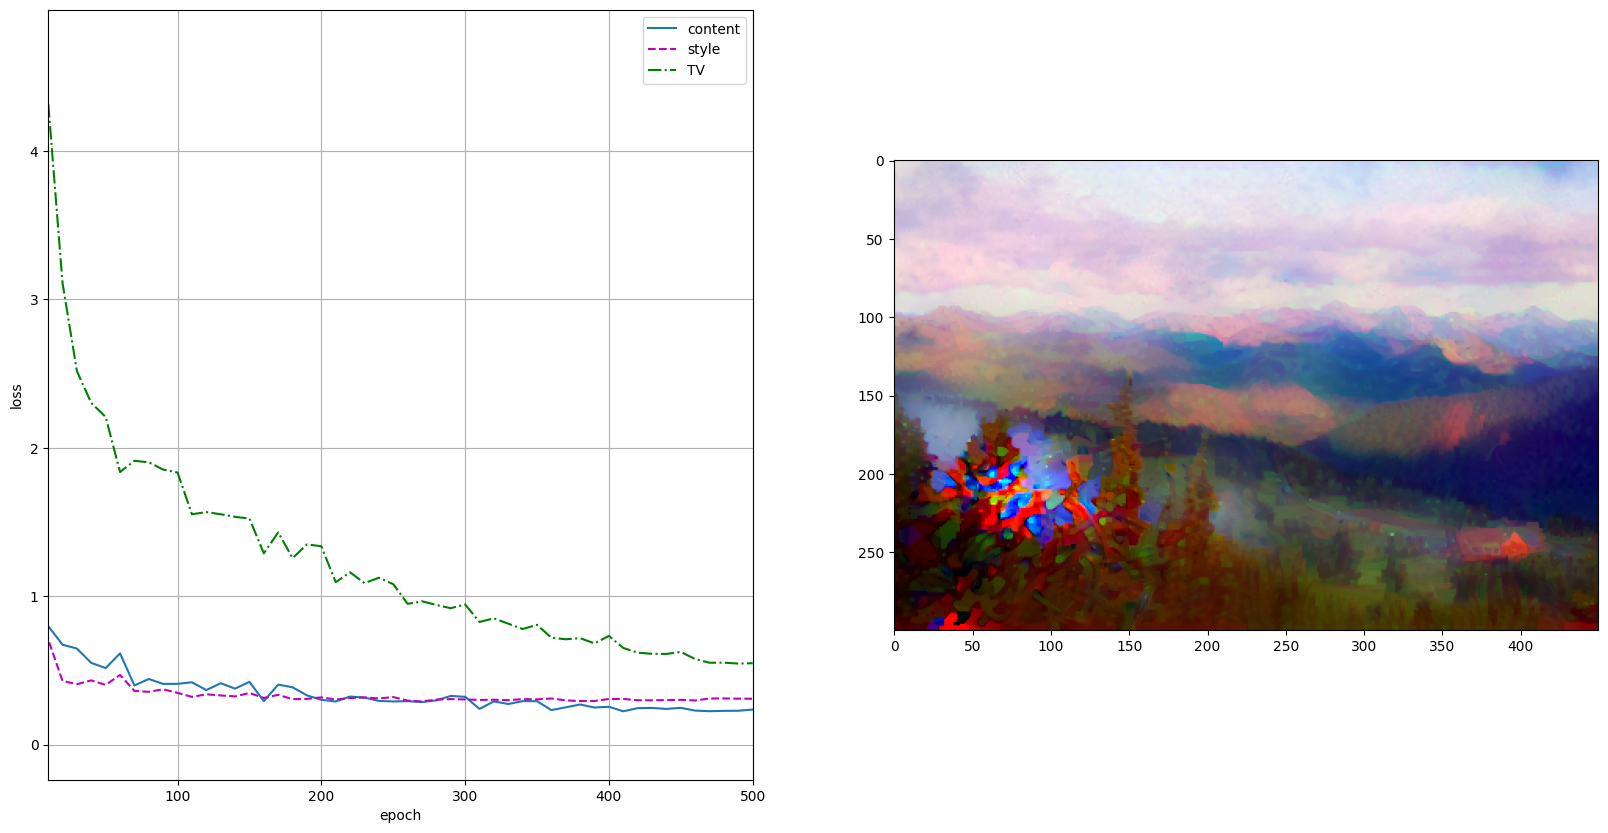

In [ ]:
# Determina si CUDA está disponible y selecciona el dispositivo correspondiente (GPU si disponible, de lo contrario, CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define el tamaño de la imagen de entrada como una tupla (altura, ancho)
image_shape = (300, 450)  # PIL Image (h, w)

# Mueve la red neuronal `net` al dispositivo seleccionado
net = net.to(device)

# Obtiene las características de contenido de la imagen de contenido y las características de contenido (`content_X`, `contents_Y`) utilizando la función `get_contents`
content_X, contents_Y = get_contents(image_shape, device)

# Obtiene las características de estilo de la imagen de estilo (`styles_Y`) utilizando la función `get_styles`
_, styles_Y = get_styles(image_shape, device)

# Entrena la imagen de contenido (`content_X`) para adoptar el estilo de la imagen de estilo
#proporcionada durante 500 épocas, con una tasa de aprendizaje inicial de 0.3 y un ajuste de la tasa de aprendizaje cada 50 épocas
output = train(content_X, contents_Y, styles_Y, device, 0.3, 500, 50)


Podemos ver que la imagen sintetizada retiene el escenario y los objetos de la imagen de contenido y transfiere el color de la imagen de estilo al mismo tiempo. Por ejemplo, la imagen sintetizada tiene bloques de color como los de la imagen de estilo. Algunos de estos bloques incluso tienen la sutil textura de las pinceladas.